Load Dataset

In [1]:
import pandas as pd
import seaborn as sns


df = sns.load_dataset("mpg")


print(df.head(10))


print("Dataset Shape:", df.shape)


print("Columns:", df.columns)

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   
5  15.0          8         429.0       198.0    4341          10.0   
6  14.0          8         454.0       220.0    4354           9.0   
7  14.0          8         440.0       215.0    4312           8.5   
8  14.0          8         455.0       225.0    4425          10.0   
9  15.0          8         390.0       190.0    3850           8.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa         

Data Cleaning

In [2]:

print(df.isnull().sum())


df = df.dropna(subset=["mpg"])


df["horsepower"].fillna(df["horsepower"].median(), inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
Missing values after cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


/tmp/ipython-input-474/1703537915.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["horsepower"].fillna(df["horsepower"].median(), inplace=True)


Feature Selection

In [4]:
X = df[["cylinders", "horsepower", "weight", "displacement"]]
y = df["mpg"]

Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (318, 4)
Testing Size: (80, 4)


Build Linear Regression Model

In [6]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Coefficients:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)

Coefficients: [-0.18620277 -0.04028329 -0.00531685 -0.00561704]
Intercept: 45.637601052709044


Evaluate Linear Regression

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_linear = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.119194817737374
MSE: 14.670426917488303
RMSE: 3.830199331299652
R2 Score: 0.7271452992929572


Polynomial Regression

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


poly2_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly2_model.fit(X_train, y_train)


poly3_model = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly3_model.fit(X_train, y_train)


print("Degree 2 R2 Train:", poly2_model.score(X_train, y_train))
print("Degree 2 R2 Test:", poly2_model.score(X_test, y_test))

print("Degree 3 R2 Train:", poly3_model.score(X_train, y_train))
print("Degree 3 R2 Test:", poly3_model.score(X_test, y_test))

Degree 2 R2 Train: 0.7544233511569484
Degree 2 R2 Test: 0.778155152872776
Degree 3 R2 Train: 0.7828273759934901
Degree 3 R2 Test: 0.7808241296093856


Learning Curve

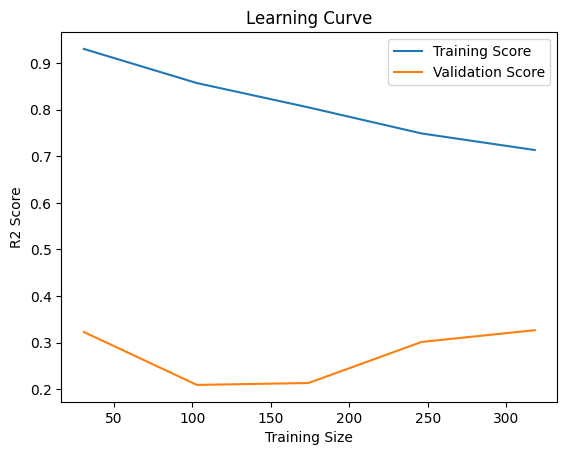

In [9]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    linear_model, X, y, cv=5, scoring="r2"
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.legend()
plt.title("Learning Curve")
plt.show()

Validation Curve

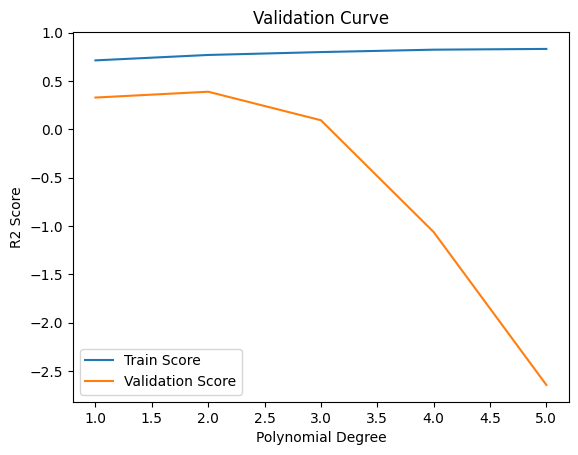

In [10]:
from sklearn.model_selection import validation_curve

param_range = [1, 2, 3, 4, 5]

train_scores, val_scores = validation_curve(
    make_pipeline(PolynomialFeatures(), LinearRegression()),
    X, y,
    param_name="polynomialfeatures__degree",
    param_range=param_range,
    cv=5,
    scoring="r2"
)

plt.plot(param_range, train_scores.mean(axis=1), label="Train Score")
plt.plot(param_range, val_scores.mean(axis=1), label="Validation Score")
plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.legend()
plt.title("Validation Curve")
plt.show()